# Downscaling PSFC

In [8]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import dl4d as dds
#import dl4ds as dds
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import models

In [9]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [10]:
!python --version
#Should be Python 3.8.18

Python 3.7.12


In [11]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [12]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [13]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

# Main training code



Here you can run multiple trainings trying different combinations of predictor variables and architectures.

PSFC hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

T2 hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

PSFC lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

T2 lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Checking if model has already been tested: ('PSFC', 'T2', 'resnet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', '77', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-06 01:49:20
-------------------------------------------

2025-06-06 01:49:20.949193: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "resnet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 input_1 (InputLayer)                            [(None, 40, 40, 2)]              0                 []                                                
                                                                                                                                                      
 conv2d (Conv2D)                                 (None, 40, 40, 8)                152               ['input_1[0][0]']                                 
                                                                                                                                                      
 ResidualBlock1 (ResidualBlock)                  (None, 40, 40, 8)        

44/44 [==============================] - 146s 3s/step - loss: 0.7416 - val_loss: 0.4401
Epoch 2/77
44/44 [==============================] - ETA: 0s - loss: 0.4803

44/44 [==============================] - 138s 3s/step - loss: 0.4803 - val_loss: 0.2751
Epoch 3/77
44/44 [==============================] - ETA: 0s - loss: 0.3522

...

44/44 [==============================] - 139s 3s/step - loss: 0.1306 - val_loss: 0.0603
Epoch 22/77
44/44 [==============================] - ETA: 0s - loss: 0.1288

44/44 [==============================] - 137s 3s/step - loss: 0.1288 - val_loss: 0.0593
Epoch 23/77
44/44 [==============================] - ETA: 0s - loss: 0.1282

44/44 [==============================] - 136s 3s/step - loss: 0.1282 - val_loss: 0.0636
Epoch 24/77
44/44 [==============================] - ETA: 0s - loss: 0.1267

44/44 [==============================] - 136s 3s/step - loss: 0.1267 - val_loss: 0.0618
Epoch 25/77
44/44 [==============================] - ETA: 0s - loss: 0.1249

44/44 [==============================] - 130s 3s/step - loss: 0.1249 - val_loss: 0.0642
Epoch 25: early stopping
9/9 [==============================] - 4s 405ms/step - loss: 0.0625

Score on the test set: 0.06248318776488304
--------------------------------------------------------------------------------
Final running time: 0:57:48.376527
--------------------------------------------------------------------------------


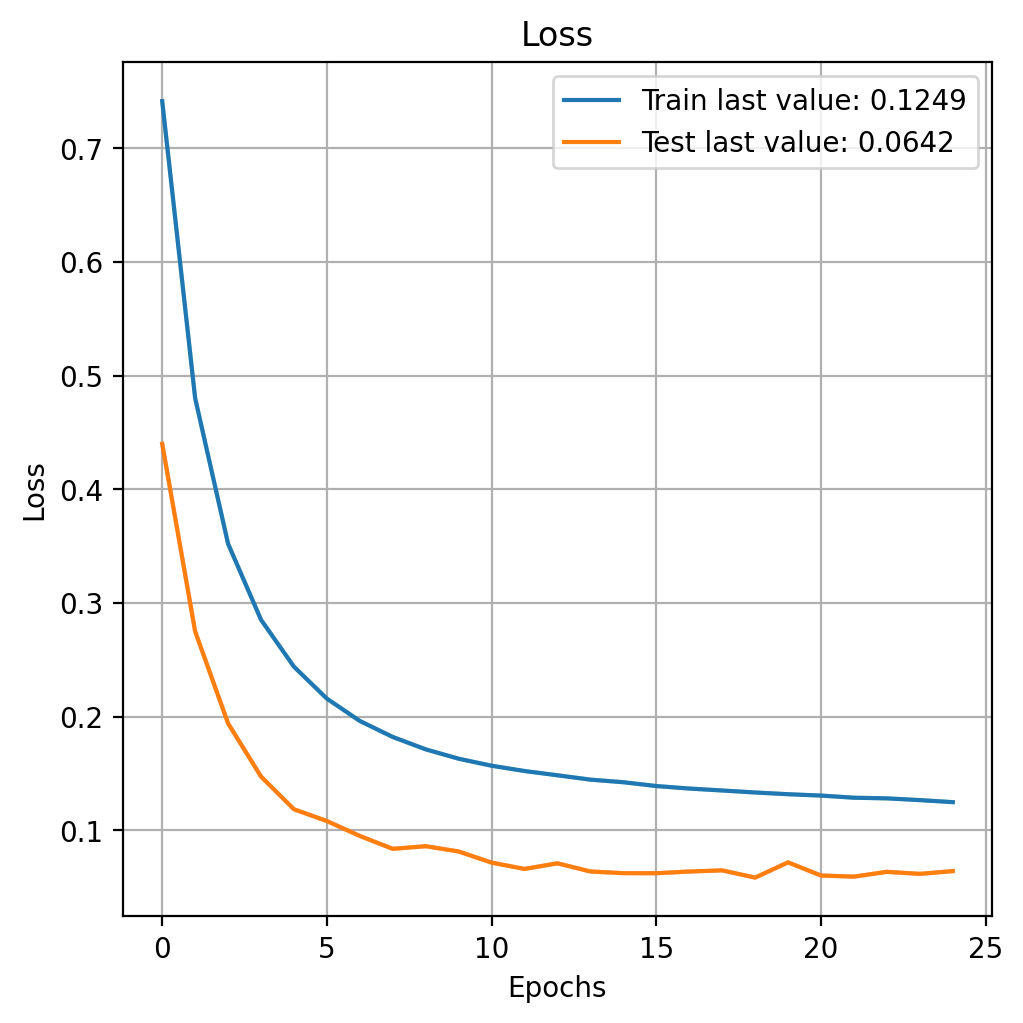

Running model with backbone=densenet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Running model with backbone=densenet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Checking if model has already been tested: ('PSFC', 'T2', 'densenet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', '77', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-06 02:47:45
--------------------------------------------------------------------------------
Model: "densenet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     

44/44 [==============================] - 237s 5s/step - loss: 0.6237 - val_loss: 0.4517
Epoch 2/77
44/44 [==============================] - ETA: 0s - loss: 0.3645

44/44 [==============================] - 220s 5s/step - loss: 0.3645 - val_loss: 0.2177
Epoch 3/77
44/44 [==============================] - ETA: 0s - loss: 0.2660

44/44 [==============================] - 216s 5s/step - loss: 0.2660 - val_loss: 0.1569
Epoch 4/77
44/44 [==============================] - ETA: 0s - loss: 0.2270

44/44 [==============================] - 220s 5s/step - loss: 0.2270 - val_loss: 0.1329
Epoch 5/77
44/44 [==============================] - ETA: 0s - loss: 0.2031

...

44/44 [==============================] - 206s 5s/step - loss: 0.1144 - val_loss: 0.0530
Epoch 30/77
44/44 [==============================] - ETA: 0s - loss: 0.1139

44/44 [==============================] - 211s 5s/step - loss: 0.1139 - val_loss: 0.0564
Epoch 31/77
44/44 [==============================] - ETA: 0s - loss: 0.1133

44/44 [==============================] - 220s 5s/step - loss: 0.1133 - val_loss: 0.0544
Epoch 32/77
44/44 [==============================] - ETA: 0s - loss: 0.1131

44/44 [==============================] - 217s 5s/step - loss: 0.1131 - val_loss: 0.0588
Epoch 33/77
44/44 [==============================] - ETA: 0s - loss: 0.1128

44/44 [==============================] - 214s 5s/step - loss: 0.1128 - val_loss: 0.0534
Epoch 33: early stopping
9/9 [==============================] - 5s 479ms/step - loss: 0.0528

Score on the test set: 0.052770841866731644
--------------------------------------------------------------------------------
Final running time: 2:00:13.603920
--------------------------------------------------------------------------------


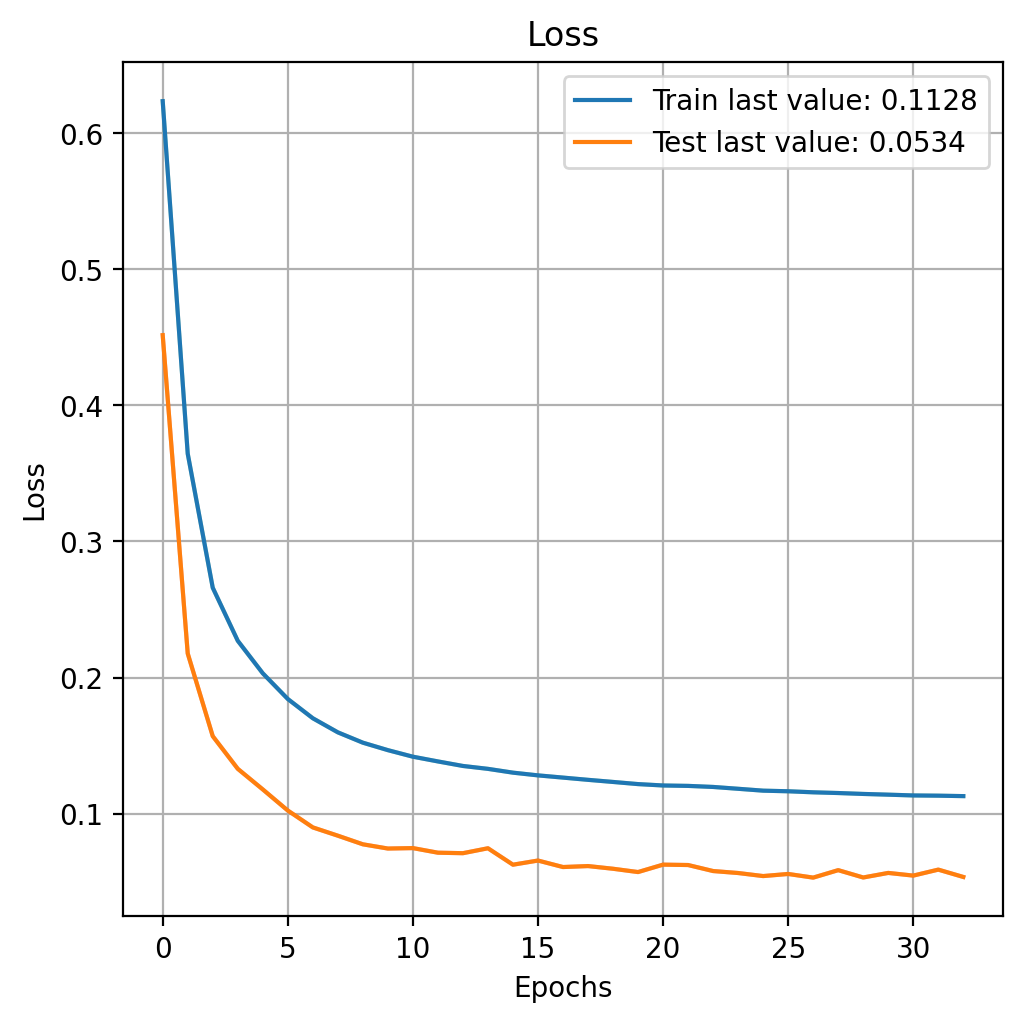

Training complete
PSFC hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

WS hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

PSFC lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

WS lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Checking if model has already been tested: ('PSFC', 'WS', 'resnet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', '77', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-06 04:48:44
-------------------------

44/44 [==============================] - 159s 3s/step - loss: 0.7900 - val_loss: 0.6736
Epoch 2/77
44/44 [==============================] - ETA: 0s - loss: 0.6489

44/44 [==============================] - 142s 3s/step - loss: 0.6489 - val_loss: 0.4635
Epoch 3/77
44/44 [==============================] - ETA: 0s - loss: 0.4789

44/44 [==============================] - 132s 3s/step - loss: 0.4789 - val_loss: 0.2643
Epoch 4/77
44/44 [==============================] - ETA: 0s - loss: 0.3656

44/44 [==============================] - 143s 3s/step - loss: 0.3656 - val_loss: 0.1912
Epoch 5/77
44/44 [==============================] - ETA: 0s - loss: 0.3012

...

44/44 [==============================] - 145s 3s/step - loss: 0.1209 - val_loss: 0.0636
Epoch 44/77
44/44 [==============================] - ETA: 0s - loss: 0.1208

44/44 [==============================] - 142s 3s/step - loss: 0.1208 - val_loss: 0.0593
Epoch 45/77
44/44 [==============================] - ETA: 0s - loss: 0.1186

44/44 [==============================] - 133s 3s/step - loss: 0.1186 - val_loss: 0.0619
Epoch 46/77
44/44 [==============================] - ETA: 0s - loss: 0.1182

44/44 [==============================] - 147s 3s/step - loss: 0.1182 - val_loss: 0.0553
Epoch 47/77
44/44 [==============================] - ETA: 0s - loss: 0.1177

44/44 [==============================] - 144s 3s/step - loss: 0.1177 - val_loss: 0.0553
Epoch 47: early stopping
9/9 [==============================] - 5s 584ms/step - loss: 0.0530

Score on the test set: 0.053020648658275604
--------------------------------------------------------------------------------
Final running time: 1:49:39.138758
--------------------------------------------------------------------------------


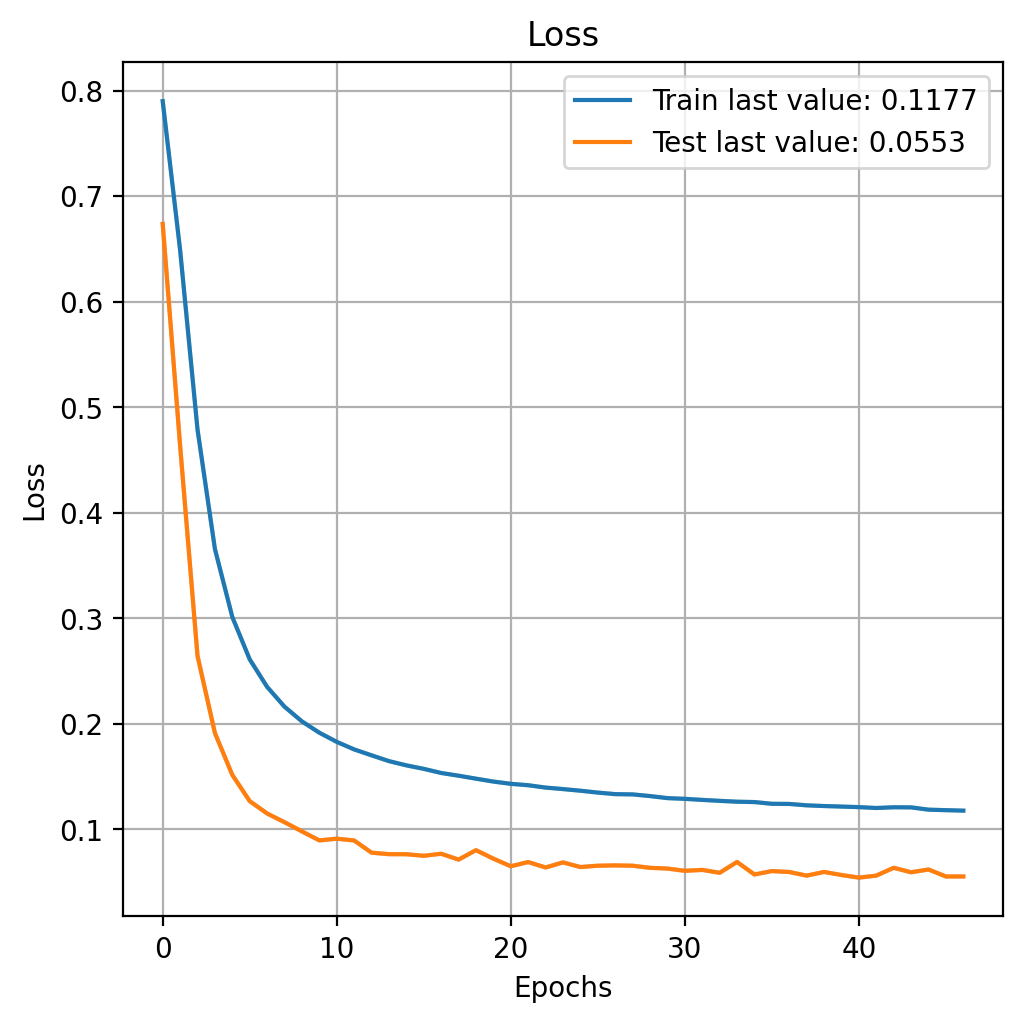

Running model with backbone=densenet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Running model with backbone=densenet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Checking if model has already been tested: ('PSFC', 'WS', 'densenet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', '77', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-06 06:39:00
--------------------------------------------------------------------------------
Model: "densenet_spc"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     

44/44 [==============================] - 242s 5s/step - loss: 0.6051 - val_loss: 0.3273
Epoch 2/77
44/44 [==============================] - ETA: 0s - loss: 0.3623

44/44 [==============================] - 214s 5s/step - loss: 0.3623 - val_loss: 0.2003
Epoch 3/77
44/44 [==============================] - ETA: 0s - loss: 0.2838

44/44 [==============================] - 222s 5s/step - loss: 0.2838 - val_loss: 0.1509
Epoch 4/77
44/44 [==============================] - ETA: 0s - loss: 0.2415

44/44 [==============================] - 213s 5s/step - loss: 0.2415 - val_loss: 0.1247
Epoch 5/77
44/44 [==============================] - ETA: 0s - loss: 0.2151

...

44/44 [==============================] - 187s 4s/step - loss: 0.1287 - val_loss: 0.0576
Epoch 28/77
44/44 [==============================] - ETA: 0s - loss: 0.1283

44/44 [==============================] - 173s 4s/step - loss: 0.1283 - val_loss: 0.0585
Epoch 29/77
44/44 [==============================] - ETA: 0s - loss: 0.1279

44/44 [==============================] - 190s 4s/step - loss: 0.1279 - val_loss: 0.0633
Epoch 30/77
44/44 [==============================] - ETA: 0s - loss: 0.1286

44/44 [==============================] - 171s 4s/step - loss: 0.1286 - val_loss: 0.0576
Epoch 31/77
44/44 [==============================] - ETA: 0s - loss: 0.1264

44/44 [==============================] - 191s 4s/step - loss: 0.1264 - val_loss: 0.0575
Epoch 31: early stopping
9/9 [==============================] - 6s 620ms/step - loss: 0.0548

Score on the test set: 0.054789647459983826
--------------------------------------------------------------------------------
Final running time: 1:42:06.594054
--------------------------------------------------------------------------------


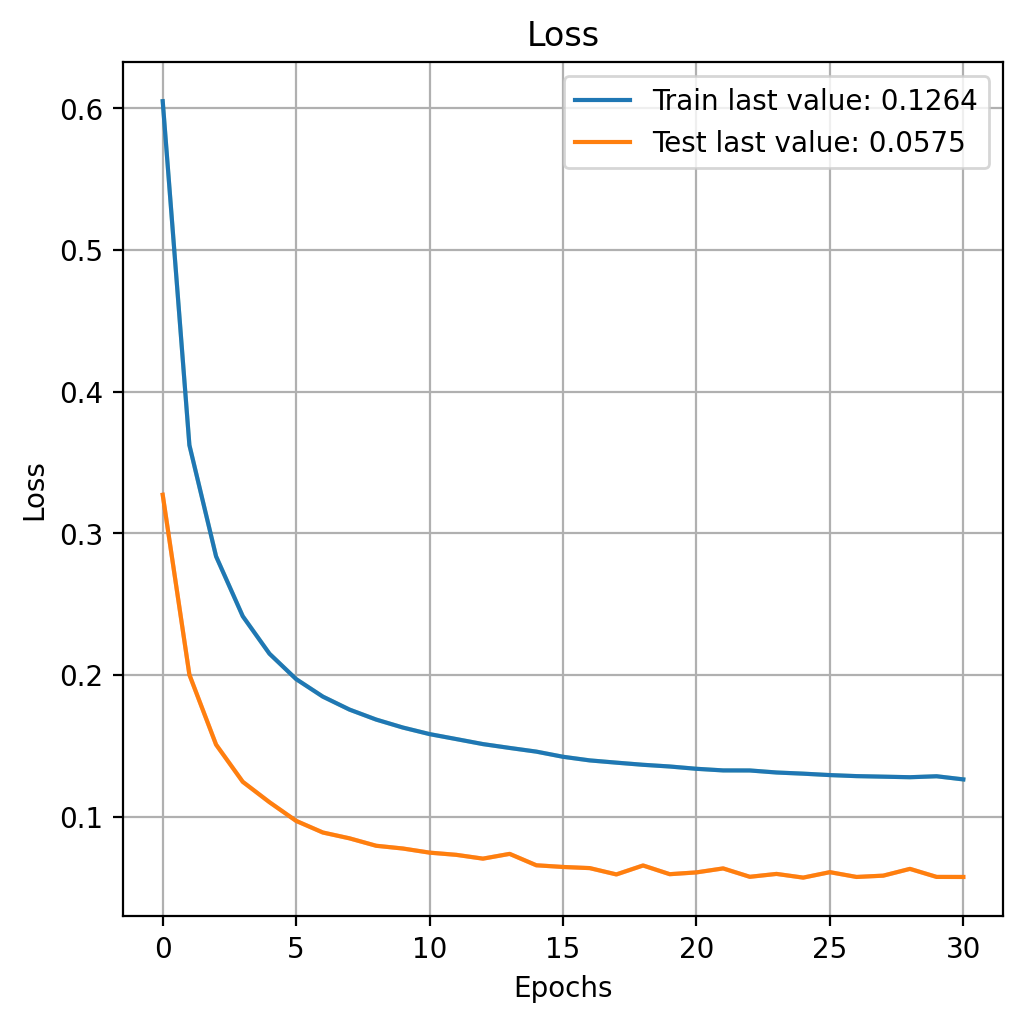

Training complete
PSFC hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

PBLH hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

PSFC lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

PBLH lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 60
Checking if model has already been tested: ('PSFC', 'PBLH', 'resnet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', '77', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-06 08:21:36
-------------------

44/44 [==============================] - 132s 3s/step - loss: 0.6161 - val_loss: 0.2853
Epoch 2/77
44/44 [==============================] - ETA: 0s - loss: 0.3320

44/44 [==============================] - 119s 3s/step - loss: 0.3320 - val_loss: 0.1541
Epoch 3/77
44/44 [==============================] - ETA: 0s - loss: 0.2540

44/44 [==============================] - 120s 3s/step - loss: 0.2540 - val_loss: 0.1208
Epoch 4/77
44/44 [==============================] - ETA: 0s - loss: 0.2105

44/44 [==============================] - 125s 3s/step - loss: 0.2105 - val_loss: 0.1018
Epoch 5/77
44/44 [==============================] - ETA: 0s - loss: 0.1836

...

44/44 [==============================] - 121s 3s/step - loss: 0.1331 - val_loss: 0.0592
Epoch 11/77
44/44 [==============================] - ETA: 0s - loss: 0.1315

44/44 [==============================] - 117s 3s/step - loss: 0.1315 - val_loss: 0.0580
Epoch 12/77
44/44 [==============================] - ETA: 0s - loss: 0.1275

44/44 [==============================] - 123s 3s/step - loss: 0.1275 - val_loss: 0.0674
Epoch 13/77
44/44 [==============================] - ETA: 0s - loss: 0.1247

44/44 [==============================] - 119s 3s/step - loss: 0.1247 - val_loss: 0.0571
Epoch 14/77
44/44 [==============================] - ETA: 0s - loss: 0.1226

44/44 [==============================] - 119s 3s/step - loss: 0.1226 - val_loss: 0.0548
Epoch 15/77
26/44 [================>.............] - ETA: 36s - loss: 0.1211

In [ ]:
####################
## DOWNSCALING PSFC ##
####################

var_list = ['PSFC']
pred_var_list = ['T2', 'WS', 'PBLH', 'SWDOWN']

for var in var_list:
    for pred_var in pred_var_list:
        #High resolution (uWRF) data
        var_hr_train = uwrf_train[var]
        var_hr_val = uwrf_val[var]
        var_hr_test = uwrf_test[var]

        pred_var_hr_train = uwrf_train[pred_var]
        pred_var_hr_val = uwrf_val[pred_var]
        pred_var_hr_test = uwrf_test[pred_var]

        #--------------------------
        #Low resolution (NAM) data
        var_lr_train = nam_train[var]
        var_lr_val = nam_val[var]
        var_lr_test = nam_test[var]

        pred_var_lr_train = nam_train[pred_var]
        pred_var_lr_val = nam_val[pred_var]
        pred_var_lr_test = nam_test[pred_var]
        
        var_scaler_train = dds.StandardScaler(axis=None)
        var_scaler_train.fit(var_hr_train)  

        pred_var_scaler_train = dds.StandardScaler(axis=None)
        pred_var_scaler_train.fit(pred_var_hr_train)
        #----------------------------------------------
        #High resolution (uWRF):
        y_train = var_scaler_train.transform(var_hr_train)
        y_val = var_scaler_train.transform(var_hr_val)
        y_test = var_scaler_train.transform(var_hr_test)


        y_z_train = pred_var_scaler_train.transform(pred_var_hr_train)
        y_z_val = pred_var_scaler_train.transform(pred_var_hr_val)
        y_z_test = pred_var_scaler_train.transform(pred_var_hr_test)

        #-------------------------------------------------
        #Low resolution (NAM)

        x_train = var_scaler_train.transform(var_lr_train)
        x_val = var_scaler_train.transform(var_lr_val)
        x_test = var_scaler_train.transform(var_lr_test)

        x_z_train = pred_var_scaler_train.transform(pred_var_lr_train)
        x_z_val = pred_var_scaler_train.transform(pred_var_lr_val)
        x_z_test = pred_var_scaler_train.transform(pred_var_lr_test)
        
        y_train = y_train.expand_dims(dim='channel', axis=-1)
        y_val = y_val.expand_dims(dim='channel', axis=-1)
        y_test = y_test.expand_dims(dim='channel', axis=-1)

        y_z_train = y_z_train.expand_dims(dim ='channel', axis=-1)
        y_z_val = y_z_val.expand_dims(dim ='channel', axis=-1)
        y_z_test = y_z_test.expand_dims(dim ='channel', axis=-1)

        #-----------------------------------------------------

        x_train = x_train.expand_dims(dim='channel', axis=-1)
        x_val = x_val.expand_dims(dim='channel', axis=-1)
        x_test = x_test.expand_dims(dim='channel', axis=-1)

        x_z_train = x_z_train.expand_dims(dim ='channel', axis=-1)
        x_z_val = x_z_val.expand_dims(dim ='channel', axis=-1)
        x_z_test = x_z_test.expand_dims(dim ='channel', axis=-1)
        
        print(f"{var} hr data shape:")
        print(y_train.shape, y_val.shape, y_test.shape)
        print("")
        print(f"{pred_var} hr data shape:")
        print(y_z_train.shape, y_z_val.shape, y_z_test.shape)
        print("")
        print(f"{var} lr data shape:")
        print(x_train.shape, x_val.shape, x_test.shape)
        print("")
        print(f"{pred_var} lr data shape:")
        print(x_z_train.shape, x_z_val.shape, x_z_test.shape)

        
        
        import os
        import shutil
        import csv
        import pandas as pd

        pred_var_train = [y_z_train]
        pred_var_val = [y_z_val]
        pred_var_test = [y_z_test]

        #------------------------------------------------------------------------------------
        results = []
        best_loss = float('inf')
        best_model_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Best-Model" #**change**
        other_models_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Other-Models" #**change**
        test_loss_file = os.path.join(other_models_path, "test_loss.txt")
        runtime_file = os.path.join(other_models_path, "running_time.txt")
        csv_file = f"/home/gvaillant1/downscaling/results/{var}_model_results.csv" #**change**
        results = pd.read_csv(csv_file)
        #------------------------------------------------------------------------------------
        #TESTING DIFFERENT HYPER PARAMETERS:
        #change the hyperparams to test different models
        backbones = ['resnet', 'densenet']
        num_filters = [8] 
        num_blocks = [8]
        epochs = [77]
        lrate_values = (1e-3, 1e-4)
        local_layer=True
        #------------------------------------------------------------------------------------

        #Check the existing results csv file to see if the parameter combination has already been tested
        existing_results = []
        if os.path.exists(csv_file):
            with open(csv_file, "r") as f:
                reader = csv.reader(f)
                next(reader, None)  # Skip header
                for row in reader:
                    existing_results.append(tuple(row))

        # Retrieve the lowest loss from CSV before training
        if existing_results:
            best_loss = min(float(row[2]) for row in existing_results if row[2] != "NULL")

        min_losses = {}

        for backbone in backbones:
            for filters in num_filters:
                for blocks in num_blocks:
                    for epoch in epochs:
                        for lr in lrate_values:
                            ARCH_PARAMS = dict(n_filters=filters,
                                               n_blocks=blocks,
                                               normalization=None,
                                               dropout_rate=0.5,
                                               dropout_variant='spatial',
                                               attention=False,
                                               activation='relu',
                                               localcon_layer=local_layer)

                            print(f"Running model with backbone={backbone}, filters={filters}, blocks={blocks}, epochs={epoch}")

                            trainer = dds.SupervisedTrainer(
                                backbone=backbone,
                                upsampling='spc',
                                data_train=y_train,
                                data_val=y_val,
                                data_test=y_test,
                                data_train_lr=None,
                                data_val_lr=None,
                                data_test_lr=None,
                                scale=3,
                                time_window=None,
                                static_vars=None,
                                predictors_train=pred_var_train, #Add predictor information here (not required)
                                predictors_val=pred_var_val, #Add predictor information here (not required)
                                predictors_test=pred_var_test, #Add predictor informatio here (not required)
                                interpolation='inter_area',
                                patch_size=None,
                                batch_size=60,
                                loss='mae',
                                epochs=epoch,
                                steps_per_epoch=None,
                                validation_steps=None,
                                test_steps=None,
                                learning_rate=lr,
                                lr_decay_after=1e4,
                                early_stopping=True,
                                patience=6,
                                min_delta=0,
                                save=True,
                                save_bestmodel=True,
                                save_path=other_models_path,
                                show_plot=True,
                                verbose=True,
                                device='CPU',
                                **ARCH_PARAMS)

                        # Create unique model identifier (ensure all fields match CSV format)
                        #Needed to specify the datatypes so the code will be able to correctly check if we have done the model before
                        model_id = (str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                    backbone, str(filters), str(blocks), str(lrate_values), trainer.interpolation, trainer.upsampling, 
                                    str(trainer.epochs), trainer.loss, str(trainer.early_stopping), str(local_layer), str(trainer.device))

                        model_id = (
                            str(y_train.name),
                            "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                            backbone,
                            str(filters),
                            str(blocks),
                            str(lrate_values),
                            trainer.interpolation,
                            trainer.upsampling,
                            str(trainer.epochs),
                            trainer.loss,
                            str(trainer.early_stopping),
                            str(local_layer),
                            str(trainer.device)
                        )

                        print(f"Checking if model has already been tested: {model_id}")

                        #Check if model already exists in CSV
                        model_exists = False
                        for row in existing_results:
                            existing_model_id = (row[0], row[1], row[3], row[4], row[5], row[11], 
                                                 row[9], row[8], row[6], row[12], row[13], row[16], row[17])
                            #print(f"Comparing with existing model: {existing_model_id}")

                            if existing_model_id == model_id:
                                print("Match found! Skipping training for:", model_id)
                                model_exists = True
                                break

                        if model_exists:
                            continue

                        trainer.run()

                        if os.path.exists(test_loss_file):
                            with open(test_loss_file, "r") as f:
                                val_loss = float(f.read().strip())
                        else:
                            val_loss = float('inf')

                        if os.path.exists(runtime_file):
                            with open(runtime_file, "r") as f:
                                training_runtime = f.read().strip()
                        else:
                            training_runtime = "NULL"

                        model_save_path = other_models_path  # Default save path

                        #Check if the loss we just calculated is the lowest
                        #If so, it is the best model and it should be put in the best model directory


                        #Set the dictionary holding the lowest loss values.
                        #This assumes that the results file has some data in it already
                        for ele in results['Loss Function'].unique():
                            value = results.loc[results['Loss Function'] == ele, 'Test Loss'].values
                            min_losses[ele] = min(value)

                        for key, value in min_losses.items():
                            if trainer.loss == key and val_loss < value:
                                min_losses[trainer.loss] = val_loss

                        #print(min_losses)


                            # Remove previous best model completely before replacing it
                                if os.path.exists(best_model_path):
                                    shutil.rmtree(best_model_path)  # Delete the entire directory

                                # Move new best model to the best model directory
                                shutil.move(other_models_path, best_model_path)
                                model_save_path = best_model_path #replace the model_save_path with the best model path if it has a lower loss
                                print('Moved to best model directory')

                            results = results.append(
                                        pd.DataFrame([[
                                            str(y_train.name), 
                                            "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                            val_loss, 
                                            backbone, 
                                            filters, 
                                            blocks, 
                                            trainer.epochs, 
                                            trainer.model.count_params(), 
                                            trainer.upsampling, 
                                            trainer.interpolation, 
                                            trainer.batch_size, 
                                            lrate_values, 
                                            trainer.loss, 
                                            trainer.early_stopping, 
                                            training_runtime, 
                                            model_save_path, 
                                            local_layer, 
                                            trainer.device
                                        ]], columns=["Downscaled Variable", "Predictor", "Test Loss",
                                                     "Backbone", "Filters", "Blocks",
                                                     "Epochs", "Parameters", "Upsampling Method",
                                                     "Interpolation Method", "Batch Size", "Learning Rate",
                                                     "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                                    )



                        #Write the information about the model and results in the results CSV file
                        file_exists = os.path.isfile(csv_file)
                        with open(csv_file, mode='a', newline='') as f:
                            writer = csv.writer(f)
                            if not file_exists:
                                writer.writerow(["Downscaled Variable", "Predictor", "Test Loss",
                                                 "Backbone", "Filters", "Blocks",
                                                "Epochs", "Parameters", "Upsampling Method",
                                                 "Interpolation Method", "Batch Size", "Learning Rate",
                                                "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                            writer.writerow([str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                             val_loss, backbone, filters, blocks,
                                             trainer.epochs, trainer.model.count_params(), trainer.upsampling,
                                             trainer.interpolation, trainer.batch_size, lrate_values, 
                                             trainer.loss, trainer.early_stopping, training_runtime, model_save_path, local_layer, trainer.device])

        print("Training complete")